In [5]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 5.9 MB/s eta 0:00:18
   - -------------------------------------- 2.6/101.7 MB 6.9 MB/s eta 0:00:15
   - -------------------------------------- 4.2/101.7 MB 7.1 MB/s eta 0:00:14
   -- ------------------------------------- 5.8/101.7 MB 7.4 MB/s eta 0:00:13
   -- ------------------------------------- 7.6/101.7 MB 7.5 MB/s eta 0:00:13
   --- ------------------------------------ 9.4/101.7 MB 7.7 MB/s eta 0:00:12
   ---- ----------------------------------- 10.7/101.7 MB 7.7 MB/s eta 0:00:12
   ---- ----------------------------------- 12.6/101.7 MB 7.7 MB/s eta 0:00:12
   ----- ---------------------------------- 14.2/101.7 MB 7.8 MB/s eta 0:00:12
   ------ --------------------------------- 16.0/101.7 MB 7.8 MB/s eta 0:00:11
   ------ --------------------------------- 17.6/101.7 MB 7.8 MB/s eta 0:00:11
   ------- -------------------------------- 18.9/101.7 MB 7.6 MB/s


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.signal import hilbert

# Librerías de Machine Learning (Scikit-Learn y XGBoost)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Cargar los datos procesados en proyecto 1
X_raw = np.load("X_epocas_procesadas_ml.npy") # (Épocas, Canales, Tiempos)
y = np.load("y_etiquetas_ml.npy")             # (Épocas,)

print(f"Datos cargados exitosamente.")
print(f"Tenemos {X_raw.shape[0]} épocas para entrenamiento.")

Datos cargados exitosamente.
Tenemos 4898 épocas para entrenar a la IA.


In [ ]:
def extraer_caracteristicas(eeg_procesado, idx_c3=8, idx_c4=12):
    """
    Extracción vectorial de características para BCI.
    """
    print("Extrayendo características matemáticas...")
    
    # A. Potencia Espectral (PSD Simulada con FFT rápida)
    fft_vals = np.abs(np.fft.rfft(eeg_procesado, axis=2))
    psd_all = fft_vals ** 2
    psd_features = np.mean(psd_all, axis=2) # Potencia media por canal
    
    # B. Entropía Espectral (Complejidad)
    psd_norm = psd_all / np.sum(psd_all, axis=2, keepdims=True)
    entropia_features = -np.sum(psd_norm * np.log2(psd_norm + 1e-12), axis=2)
    
    # C. Asimetría Interhemisférica (C3 vs C4)
    pot_c3 = psd_features[:, idx_c3]
    pot_c4 = psd_features[:, idx_c4]
    asimetria_feature = ((pot_c3 - pot_c4) / (pot_c3 + pot_c4))[:, np.newaxis]
    
    # D. Sincronización Funcional (PLV)
    fase_c3 = np.angle(hilbert(eeg_procesado[:, idx_c3, :], axis=-1))
    fase_c4 = np.angle(hilbert(eeg_procesado[:, idx_c4, :], axis=-1))
    plv_feature = np.abs(np.mean(np.exp(1j * (fase_c3 - fase_c4)), axis=-1))[:, np.newaxis]
    
    # E. Concatenación final (Matriz X tabular)
    # Forma resultante: [Potencias(64), Entropías(64), Asimetría(1), PLV(1)] = 130 columnas
    X_features = np.hstack([psd_features, entropia_features, asimetria_feature, plv_feature])
    
    return X_features

# Ejecutar la función
X_tabular = extraer_caracteristicas(X_raw, idx_c3=8, idx_c4=12)
print(f"Matriz de características lista. Forma final: {X_tabular.shape}")

Extrayendo características matemáticas...
Matriz de características lista. Forma final: (4898, 130)


Iniciando entrenamiento K-Fold (5 iteraciones)...
\n✅ Entrenamiento finalizado.
Precisión media SVM: 55.78% (+/- 1.31%)
Precisión media XGBoost: 55.27% (+/- 0.52%)


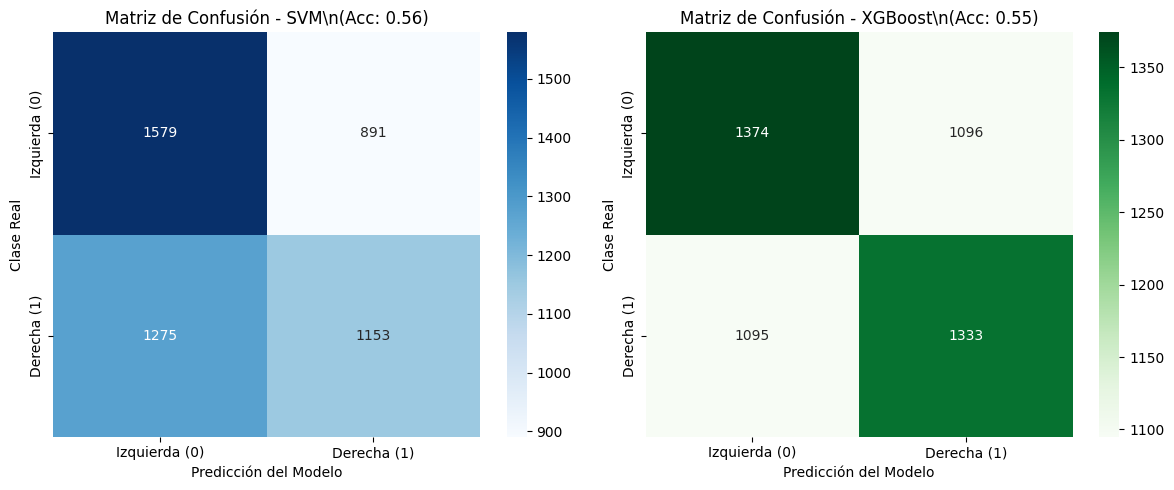

In [ ]:
# 1. Configurar Validación Cruzada (5-Fold Stratified)
# Esto asegura que haya la misma proporción de izquierda/derecha en cada pliegue
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Variables para acumular resultados
acc_svm, acc_xgb = [], []
matriz_svm = np.zeros((2, 2))
matriz_xgb = np.zeros((2, 2))

print("Iniciando entrenamiento K-Fold (5 iteraciones)...")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tabular, y)):
    # Separar datos
    X_train, X_test = X_tabular[train_idx], X_tabular[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # ESTANDARIZACIÓN (Crucial para que SVM funcione bien)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ----------------------------------------------------
    # MODELO 1: Support Vector Machine (SVM)
    # Busca un hiperplano que separe la clase 0 de la clase 1
    # ----------------------------------------------------
    modelo_svm = SVC(kernel='rbf', C=1.0, random_state=42)
    modelo_svm.fit(X_train_scaled, y_train)
    preds_svm = modelo_svm.predict(X_test_scaled)
    
    acc_svm.append(accuracy_score(y_test, preds_svm))
    matriz_svm += confusion_matrix(y_test, preds_svm)
    
    # ----------------------------------------------------
    # MODELO 2: Extreme Gradient Boosting (XGBoost)
    # Árboles de decisión en ensamble
    # ----------------------------------------------------
    modelo_xgb = XGBClassifier(eval_metric='logloss', random_state=42)
    modelo_xgb.fit(X_train_scaled, y_train)
    preds_xgb = modelo_xgb.predict(X_test_scaled)
    
    acc_xgb.append(accuracy_score(y_test, preds_xgb))
    matriz_xgb += confusion_matrix(y_test, preds_xgb)

print(f"\\nEntrenamiento finalizado.")
print(f"Precisión media SVM: {np.mean(acc_svm)*100:.2f}% (+/- {np.std(acc_svm)*100:.2f}%)")
print(f"Precisión media XGBoost: {np.mean(acc_xgb)*100:.2f}% (+/- {np.std(acc_xgb)*100:.2f}%)")


# MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
etiquetas = ['Izquierda (0)', 'Derecha (1)']

# Matriz SVM
sns.heatmap(matriz_svm, annot=True, fmt='g', cmap='Blues', ax=axes[0], 
            xticklabels=etiquetas, yticklabels=etiquetas)
axes[0].set_title(f'Matriz de Confusión - SVM\\n(Acc: {np.mean(acc_svm):.2f})')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Predicción del Modelo')

# Matriz XGBoost
sns.heatmap(matriz_xgb, annot=True, fmt='g', cmap='Greens', ax=axes[1], 
            xticklabels=etiquetas, yticklabels=etiquetas)
axes[1].set_title(f'Matriz de Confusión - XGBoost\\n(Acc: {np.mean(acc_xgb):.2f})')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Predicción del Modelo')

plt.tight_layout()